In [3]:
import pandas as pd
from sklearn.datasets import load_wine

df = load_wine(as_frame=True)

x = df.data
x = x[x.columns[:7]]
y = df.target
x[:5]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69


In [2]:
y.value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

Сведем задачу к бинарной классификации: будем определять, является ли вино вином типа 1 или нет.

In [4]:
y[y!=1] = 0
y.value_counts()

target
0    107
1     71
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3 ,random_state=42)

Приведем признаки к одному масштабу.


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(xtrain)

xtrain = pd.DataFrame(scaler.transform(xtrain), columns=x.columns)
xtest = pd.DataFrame(scaler.transform(xtest), columns=x.columns)

Обучим метод опорных векторов на тренировочных данных и оценим качество на тестовых данных при помощи метрики ROC-AUC.

Метрика ROC-AUC оперирует в терминах вероятностей, поэтому для ее вычисления алгоритм должен предсказывать вероятности методом predict_proba.

In [7]:
from sklearn.svm import SVC

model = SVC(kernel='linear', probability=True)
model.fit(xtrain, ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
pred = model.predict(xtest)
proba = model.predict_proba(xtest)[:,1]
proba[:10], pred[:10]

(array([0.00374254, 0.00274388, 0.00735212, 0.25233991, 0.99571508,
        0.00539557, 0.9679757 , 0.01317013, 0.9832296 , 0.01518339]),
 array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0]))

In [11]:
classes = proba > 0.8

In [12]:
from sklearn.metrics import accuracy_score, precision_score,\
      recall_score, f1_score, confusion_matrix
print('accuracy:', accuracy_score(ytest, classes))

accuracy: 0.8888888888888888


In [14]:
print('presision:', precision_score(ytest, classes))

presision: 1.0


In [15]:
print('recall:', recall_score(ytest, classes))

recall: 0.7142857142857143


In [16]:
print('f1:', f1_score(ytest, classes))

f1: 0.8333333333333334


In [13]:
confusion_matrix(ytest, classes)

array([[33,  0],
       [ 6, 15]])

Для оценки качества будем использовать ROC-AUC

In [17]:
from sklearn.metrics import roc_auc_score

pred = model.predict_proba(xtest)[:,1]
roc_auc_score(ytest, pred)

0.9624819624819625

In [19]:
classes = model.predict(xtest)
print(classes[:5])
print(pred[:5])

[0 0 0 0 1]
[0.00374254 0.00274388 0.00735212 0.25233991 0.99571508]


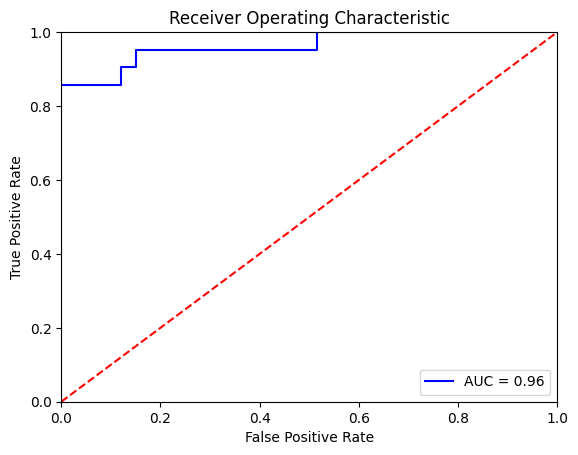

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(ytest, pred)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr,tpr,'b',label='AUC = %0.2f' % roc_auc)
plt.legend()
plt.plot([0,1],[0,1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()